# 1. Import Libraries

In [20]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization Style
sns.set_style('whitegrid')

# 2. Data Loading

In [21]:
# Load Dataset

df = pd.read_csv('data/credit_risk_dataset.csv')

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 3. Data Understanding

In [22]:
df.shape

(32581, 12)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [24]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [25]:
df.isnull().sum().sum()

4011

In [26]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [27]:
df.describe(include="object")

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


# 4. Exploratory Data Analysis (EDA)

## 4.1 Loan Status Distribution

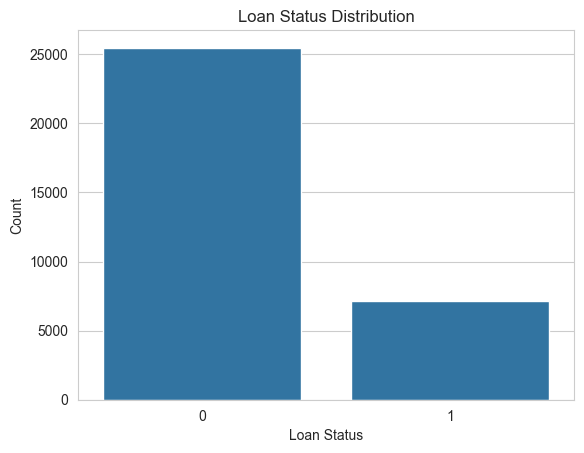

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [28]:
sns.countplot(
    x='loan_status',
    data=df
)

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

print(
    df['loan_status']
    .value_counts(normalize=True) * 100
)

### Insight

The dataset is moderately imbalanced, with approximately **78.18%** of borrowers classified as non-default and **21.82%** classified as default.

Although the dataset is not perfectly balanced, the proportion of default cases is still sufficient for building and evaluating classification models without requiring advanced resampling techniques at this stage.

## 4.2 Age Distribution

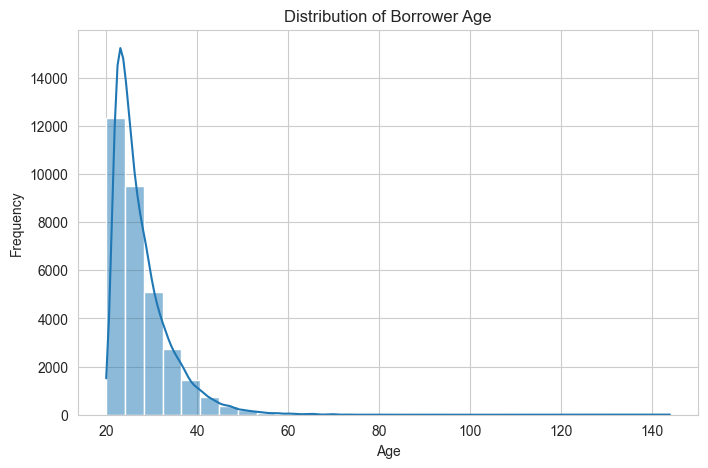

count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['person_age'],
    bins=30,
    kde=True
)

plt.title('Distribution of Borrower Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

df['person_age'].describe()

### Insight

The age distribution is heavily concentrated between 20 and 35 years old, indicating that the majority of borrowers are relatively young adults.

The distribution is positively skewed, with a small number of observations appearing at very high ages.

A maximum age of **144 years** was identified, which is not realistic and likely represents a data quality issue or outlier. This observation will be investigated further during the data preprocessing stage.

## 4.3 Age vs Loan Status

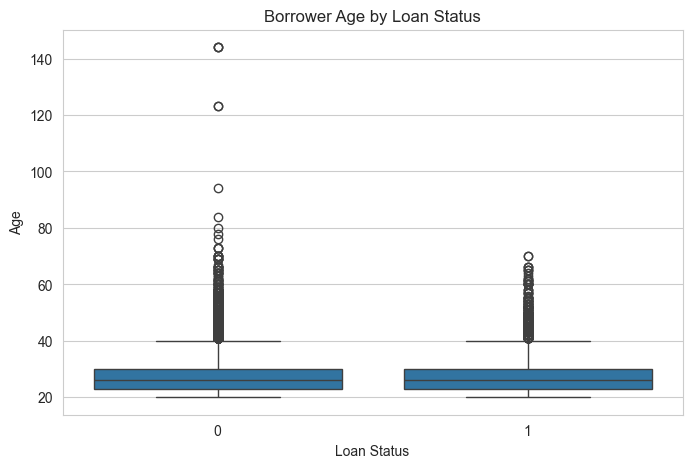

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25473.0,27.807129,6.369669,20.0,23.0,26.0,30.0,144.0
1,7108.0,27.474676,6.263642,20.0,23.0,26.0,30.0,70.0


In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='loan_status',
    y='person_age',
    data=df
)

plt.title('Borrower Age by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Age')

plt.show()

df.groupby('loan_status')['person_age'].describe()

## 4.4 Income Distribution

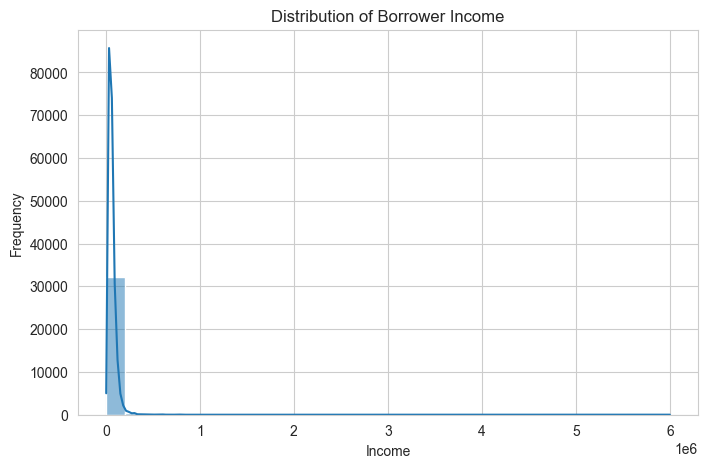

count    3.258100e+04
mean     6.607485e+04
std      6.198312e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: person_income, dtype: float64

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['person_income'],
    bins=30,
    kde=True
)

plt.title('Distribution of Borrower Income')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.show()

df['person_income'].describe()

### Insight

The income distribution is highly right-skewed, with most borrowers earning below 100,000.

Several extreme income values are present, resulting in a maximum income of **6,000,000**, which is substantially higher than the median income of **55,000**.

The large gap between the median and maximum values suggests the presence of significant outliers. These observations should be investigated further during preprocessing to ensure they do not negatively affect model performance.

## 4.5 Income vs Loan Status

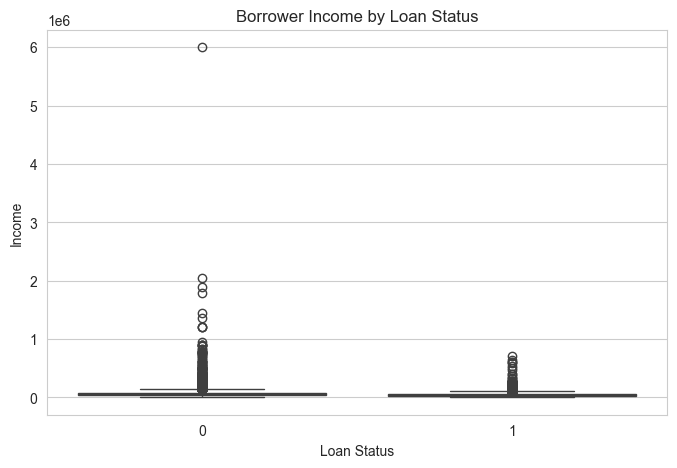

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25473.0,70804.361559,66568.802606,7000.0,42000.0,60000.0,84000.00,6000000.0
1,7108.0,49125.652223,36907.376527,4000.0,30000.0,41498.0,59497.75,703800.0


In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='loan_status',
    y='person_income',
    data=df
)

plt.title('Borrower Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Income')

plt.show()

df.groupby('loan_status')['person_income'].describe()

### Insight

Borrowers who defaulted on their loans generally have lower income levels compared to non-default borrowers.

The median income of defaulted borrowers is approximately **41,498**, while the median income of non-default borrowers is approximately **60,000**.

This suggests that lower-income borrowers may face greater difficulty meeting repayment obligations, making income a potentially important predictor of credit risk.

Several extreme income outliers are also present, particularly among non-default borrowers, with values reaching up to **6,000,000**.

## 4.6 Loan Amount Distribution

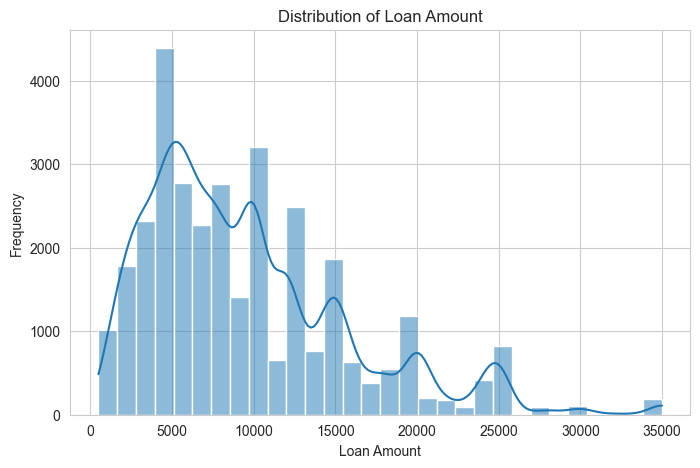

count    32581.000000
mean      9589.371106
std       6322.086646
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12200.000000
max      35000.000000
Name: loan_amnt, dtype: float64

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['loan_amnt'],
    bins=30,
    kde=True
)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

df['loan_amnt'].describe()

### Insight

The loan amount distribution is right-skewed, with most borrowers requesting loans between **5,000 and 15,000**.

The median loan amount is **8,000**, while the maximum loan amount reaches **35,000**.

A small number of borrowers request substantially larger loans, creating several high-value outliers within the dataset.

## 4.7 Loan Amount vs Loan Status

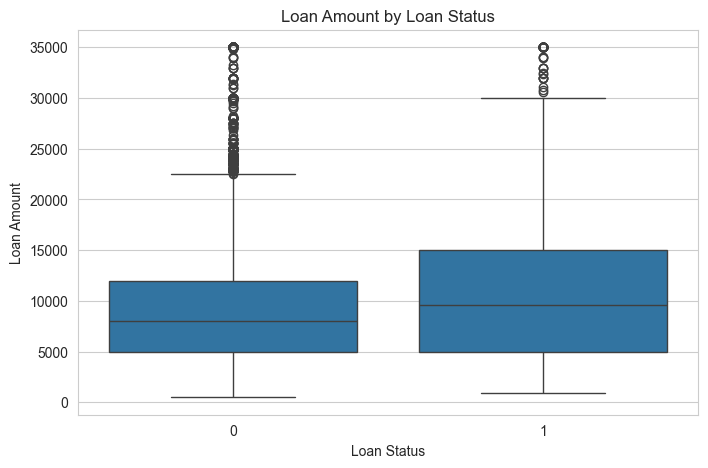

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25473.0,9237.464178,6026.375457,500.0,5000.0,8000.0,12000.0,35000.0
1,7108.0,10850.502954,7143.345344,900.0,5000.0,9600.0,15000.0,35000.0


In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='loan_status',
    y='loan_amnt',
    data=df
)

plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')

plt.show()

df.groupby('loan_status')['loan_amnt'].describe()

### Insight

Borrowers who defaulted tend to receive larger loans than non-default borrowers.

The median loan amount for defaulted borrowers is **9,600**, compared to **8,000** for non-default borrowers.

In addition, the average loan amount among defaulted borrowers is approximately **10,851**, which is noticeably higher than the **9,237** average observed among non-default borrowers.

This suggests that larger loan amounts may be associated with a higher probability of default and could be an important predictor in the credit risk model.

## 4.8 Loan Percent Income vs Loan Status

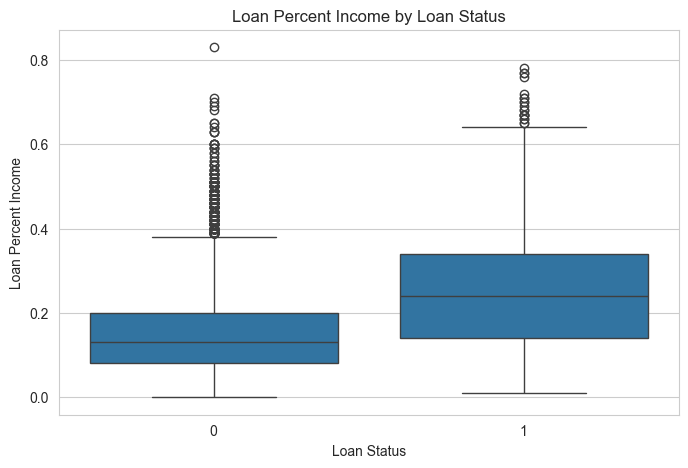

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,25473.0,0.148805,0.087252,0.00,0.08,0.13,0.20,0.83
1,7108.0,0.246889,0.132148,0.01,0.14,0.24,0.34,0.78


In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='loan_status',
    y='loan_percent_income',
    data=df
)

plt.title('Loan Percent Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Percent Income')

plt.show()

df.groupby('loan_status')['loan_percent_income'].describe()

### Insight

Borrowers who defaulted on their loans tend to have significantly higher loan-to-income ratios compared to non-default borrowers.

The median loan percent income for defaulted borrowers is approximately **24%**, while non-default borrowers have a median ratio of only **13%**.

In addition, the average loan percent income among defaulted borrowers is **24.7%**, compared to **14.9%** for non-default borrowers.

This indicates that borrowers allocating a larger proportion of their income toward loan repayment are more likely to experience repayment difficulties and ultimately default on their loans.

Therefore, loan_percent_income is expected to be one of the most important predictors of credit risk.

# 5. Data Preprocessing

In [36]:
# Create a copy of the dataset

df_model = df.copy()

df_model.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 5.1 Handle Missing Values

In [37]:
df_model.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [38]:
df_model['person_emp_length'].fillna(
    df_model['person_emp_length'].median(),
    inplace=True
)

df_model['loan_int_rate'].fillna(
    df_model['loan_int_rate'].median(),
    inplace=True
)

In [39]:
df_model.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## 5.2 Explore Categorical Features

In [40]:
categorical_cols = df_model.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df_model[col].value_counts())


person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


## 5.3 Define Features and Target

In [41]:
X = df_model.drop('loan_status', axis=1)

y = df_model['loan_status']

print(X.shape)
print(y.shape)

(32581, 11)
(32581,)


## 5.4 One-Hot Encoding

In [42]:
X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


In [43]:
X.shape

(32581, 22)

# 6. Feature Engineering

## 6.1 Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (26064, 22)
X_test shape : (6517, 22)
y_train shape: (26064,)
y_test shape : (6517,)


## 6.2 Feature Scaling

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [47]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (26064, 22)
X_test_scaled shape : (6517, 22)


### Feature Engineering Note

Feature scaling was applied using StandardScaler to standardize numerical features.

This step is particularly important for Logistic Regression because the model is sensitive to differences in feature magnitude. The scaler was fitted only on the training data to prevent data leakage.

# 7. Model Development

## 7.1 Logistic Regression

In [48]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [49]:
y_pred_lr = log_reg.predict(
    X_test_scaled
)

y_pred_prob_lr = log_reg.predict_proba(
    X_test_scaled
)[:, 1]

In [50]:
print(
    "Accuracy :",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall   :",
    recall_score(y_test, y_pred_lr)
)

print(
    "F1 Score :",
    f1_score(y_test, y_pred_lr)
)

print(
    "ROC-AUC  :",
    roc_auc_score(
        y_test,
        y_pred_prob_lr
    )
)

Accuracy : 0.8674236611938009
Precision: 0.7677543186180422
Recall   : 0.5625879043600562
F1 Score : 0.6493506493506493
ROC-AUC  : 0.8693475167320214


In [51]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517



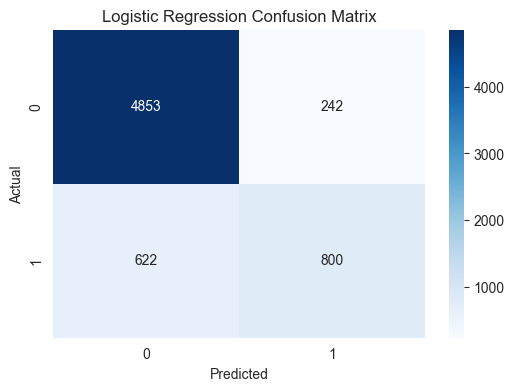

In [52]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 7.2 Random Forest

In [53]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [54]:
y_pred_rf = rf.predict(
    X_test
)

y_pred_prob_rf = rf.predict_proba(
    X_test
)[:, 1]

In [55]:
print(
    "Accuracy :",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall   :",
    recall_score(y_test, y_pred_rf)
)

print(
    "F1 Score :",
    f1_score(y_test, y_pred_rf)
)

print(
    "ROC-AUC  :",
    roc_auc_score(
        y_test,
        y_pred_prob_rf
    )
)

Accuracy : 0.9323308270676691
Precision: 0.9554317548746518
Recall   : 0.7236286919831224
F1 Score : 0.8235294117647058
ROC-AUC  : 0.9310966461424219


In [56]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



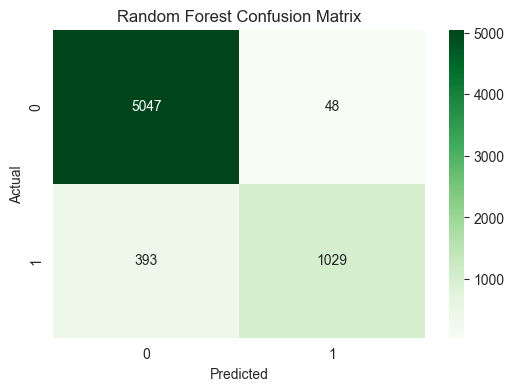

In [57]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# 8. Model Evaluation

## Model Comparison

In [58]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_prob_lr),
        roc_auc_score(y_test, y_pred_prob_rf)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.867424,0.767754,0.562588,0.649351,0.869348
1,Random Forest,0.932331,0.955432,0.723629,0.823529,0.931097


### Evaluation Insight

Random Forest outperformed Logistic Regression across all evaluation metrics.

The Random Forest model achieved an accuracy of approximately 93.23% and a ROC-AUC score of 93.11%, indicating strong discrimination between default and non-default borrowers.

In addition, Random Forest achieved a precision of 95.54%, meaning that most borrowers predicted as high-risk were correctly identified.

Based on the evaluation results, Random Forest was selected as the best-performing model for this credit risk prediction task.

# 9. Feature Importance

In [59]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,loan_percent_income,0.220112
1,person_income,0.153112
4,loan_int_rate,0.126717
3,loan_amnt,0.078264
9,person_home_ownership_RENT,0.076354
2,person_emp_length,0.059724
17,loan_grade_D,0.050213
0,person_age,0.049156
6,cb_person_cred_hist_length,0.037506
16,loan_grade_C,0.020421


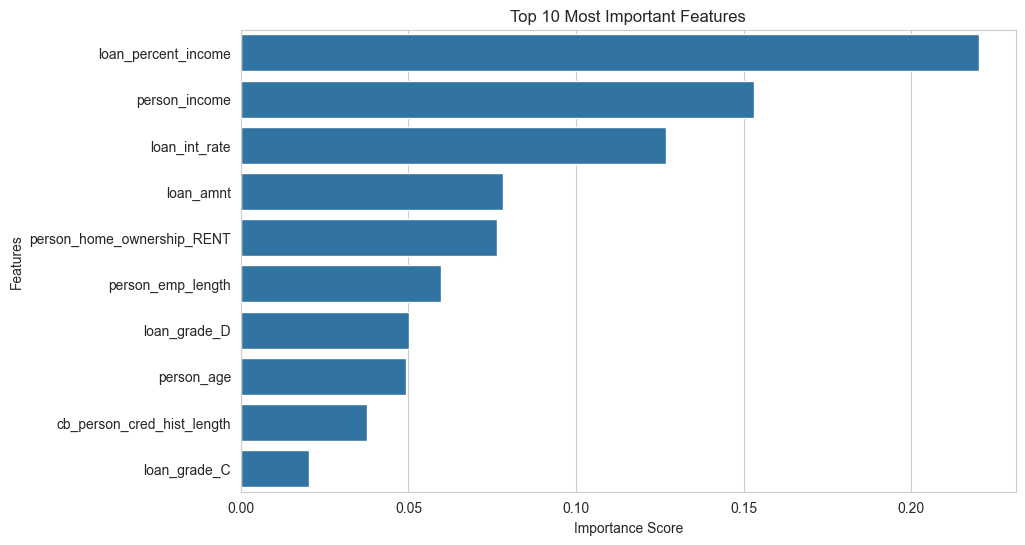

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

### Feature Importance Insight

The most influential factor in predicting loan default is `loan_percent_income`, indicating that the proportion of income allocated to loan repayment is the strongest indicator of credit risk.

Other highly important features include `person_income`, `loan_int_rate`, and `loan_amnt`, suggesting that a borrower's financial capacity and loan burden play critical roles in determining repayment behavior.

The model also identified home ownership status, employment length, and loan grade as meaningful predictors of default risk.

Overall, the feature importance results indicate that both borrower financial strength and loan characteristics significantly influence credit risk outcomes.

# 10. Business Insights

## Key Business Insights

1. Borrowers with a higher loan-to-income ratio are significantly more likely to default.

2. Lower-income borrowers exhibit a higher risk of repayment difficulties compared to higher-income borrowers.

3. Larger loan amounts are associated with increased default risk.

4. Higher interest rates are strong indicators of elevated credit risk.

5. Home ownership status contributes to creditworthiness assessment, with renters generally presenting higher risk than borrowers who own property.

# 11. Business Recommendations

## Recommendations

1. Implement stricter approval policies for applicants with high loan-to-income ratios.

2. Introduce additional risk assessments for low-income borrowers requesting large loan amounts.

3. Consider adjusting loan limits based on borrower income levels.

4. Develop risk-based pricing strategies that align interest rates with predicted default risk.

5. Utilize predictive credit risk models during the loan approval process to improve decision-making and reduce potential losses.

# 12. Conclusion

## Conclusion

This project developed machine learning models to predict borrower credit risk using demographic, financial, and loan-related information.

After comparing Logistic Regression and Random Forest, the Random Forest model achieved the best performance with an accuracy of 93.23% and a ROC-AUC score of 93.11%.

Feature importance analysis revealed that loan-to-income ratio, borrower income, interest rate, and loan amount are the most influential factors affecting default risk.

The resulting model can support financial institutions in identifying high-risk applicants, improving lending decisions, and reducing potential credit losses.